In [1]:
import random
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.preprocessing import StandardScaler
import math
import sys
import tqdm

# User Input Desired Settings

In [2]:
# change file directory to the h5 file to convert
file = h5py.File('voxel_data/output_digi_HDF_Mg22_Ne20pp_8MeV.h5', 'r')

# The following will be needed to run later cells to align event ids
original_keys = list(file.keys()) # the .keys() function lists the labels in a dictionary
original_length = len(original_keys)

In [3]:
#making an array of the lengths of events
event_lens = np.zeros(original_length, int)
for i in range(original_length):
    event = original_keys[i]
    event_lens[i] = len(file[event])

In [4]:
sample_size = 512 #enter length of number of instances per event

# x[0] ,y[1] ,z[2] ,time[3], Amplitude[4], trackID (particle ID)[5], pointID[6]
# energy[7] ,energy loss[8] ,angle[9], Mass[10], Atomic number[11], Event_id index[12], number of tracks[13]

# Enter in the CLASSIFICATION and PROJECTIONS to evaluate in all caps as projection:
# B is BINARY, T is tertiary, and FOUR is four track classiification
CLASSIFICATION = 'Voxel'
class_type = CLASSIFICATION
PROJECTION = 'XYZ'
ISOTOPE = 'Mg22'

PROJ_TO_COLS = {'XYZ': [0,1,2]}

user_input = PROJ_TO_COLS[PROJECTION]
print(class_type)
print(user_input)

Voxel
[0, 1, 2]


# Convert Raw H5 File into npArray with Corresponding key index

In [5]:
#making an array of the events data-- [event #, instance, data value]
#length of each event is based on the longest event in the dataset
#12th index now corresponds to index of event id in original_keys
# each instance will index according to the following 
# x,y,z, time, Amplitude, trackID (particle ID), pointID, energy, energy loss, angle, Mass, Atomic number, Event_id index
file_name = ISOTOPE + '_w_key_index'
event_data = np.zeros((original_length, np.max(event_lens), 13), float) 
#tqdm allows us to see the progress bar for a for loop (named after taqadum which is Arabic for progress)
for n in tqdm.tqdm(range(original_length)):
    name = original_keys[n]
    event = file[name]
    ev_len = len(event)
    #converting event into an array
    for i,e in enumerate(event):
        instant = np.array(list(e))
        event_data[n][i][:12] = np.array(instant)
        event_data[n][i][-1] = float(n) #insert index value to find corresponding event ID
np.save('voxel_data/' + file_name, event_data)

100%|██████████| 10000/10000 [05:42<00:00, 29.22it/s]


### Assertion Statements to Check the Conversion

In [6]:
data = np.load( 'voxel_data/' + ISOTOPE + '_w_key_index' + '.npy')

assert data.shape == (original_length, np.max(event_lens), 13), 'Array has incorrect shape' #making sure the data is in the right shape
assert len(np.unique(data[:,:,12])) == original_length, 'Array has incorrect Event_ids'  #making sure theres a correct amount of data points

# Random sample From New Numpy Array

In [7]:
#NOT completely random sampling!
#13th index now corresponds to the number of tracks in event, 0 = beam, 1= two track, 2 = 3 track...

# each instance will index according to the following 
# x,y,z, time, Amplitude, trackID (particle ID), pointID, energy, energy loss, angle, Mass, Atomic number, Event_id index, number of tracks


data_array = ISOTOPE + '_w_key_index.npy' #insert desired array to sample from 
new_array_name = ISOTOPE + '_size' + str(sample_size) + '_sampled'
data = np.load('voxel_data/' + data_array)
new_data = np.zeros((original_length, sample_size, 14), float) 
for i in tqdm.tqdm(range(original_length)):
    ev_len = event_lens[i]    #length of event-- i.e. number of instances
    particle_ids = data[i][:ev_len,5]
    label, distr = np.unique(particle_ids, return_counts=True)
    shortest = label[np.argmin(distr)]
    shortest_ind = np.argwhere(particle_ids == shortest)
    if ev_len == sample_size:    #if array is already preferred length
        new_data[i][:,:-1] = data[i][:ev_len,:]
    else:
        instant = 0
        for n in range(shortest_ind.size):    #the first instances sampled will be those belonging to the shortest track
            new_data[i,instant,:-1] = data[i,shortest_ind[n],:]
            instant += 1
        need = sample_size - shortest_ind.size
        random_points = np.random.choice(range(ev_len), need, replace= True if need > ev_len else False)  #choosing the random instances to sample
        for r in random_points:
            new_data[i,instant,:-1] = data[i,r,:] 
            instant += 1
    unique_point_ids = np.unique(data[i,:ev_len,5])    #array of unique particle IDs
    new_data[i][0][-1] = unique_point_ids.size - 1    #number of unique particles, scaled to start at 0
np.save('voxel_data/' + new_array_name, new_data)#creating new dataset within the h5 file for the event


100%|██████████| 10000/10000 [00:06<00:00, 1602.35it/s]


### Assertion Statements to Check the Data After Random Sampling

In [8]:
data = np.load( 'voxel_data/' + ISOTOPE + '_size' + str(sample_size) + '_sampled.npy')

assert data.shape == (original_length, sample_size, 14), 'Array has incorrect shape'
assert len(np.unique(data[:,:,13])) == len(np.unique(data[:,:,5]))-1, 'Array has incorrect number of tracks' #there should be 6 

#If the statement inside an assertion function is true nothing happens, if it isn't then the code gives an error

# Check Distribution of track labels after sampling

In [9]:
#cheking how the distribution of labels changes from sampling

name = ISOTOPE + '_size' + str(sample_size) + '_sampled'
data = np.load('voxel_data/' + name + '.npy')
real_tracks = np.zeros(original_length,int) 
sampled_tracks = np.zeros(original_length,int)

for i in range(original_length):
    ev_nt = data[i]
    real_tracks[i] = ev_nt[0,-1]
    unique_point_ids = np.unique(ev_nt[:,5])    #array of unqiue particles IDs
    sampled_tracks[i] = unique_point_ids.size - 1
    
label1, og_distr = np.unique(real_tracks, return_counts=True)
label2, new_distr = np.unique(sampled_tracks, return_counts=True)
print(og_distr)
print(label1)
print(new_distr)
print(label2)
print('Events changed = ' + str(np.sum(np.abs(new_distr - og_distr))//2))

[5002  104 2554 2319   16    5]
[0 1 2 3 4 5]
[5002  106 2554 2317   16    5]
[0 1 2 3 4 5]
Events changed = 2


## Sifting to Only Use 2, 4, & 6 Track Events

In [10]:
#creating data sets with only 4-track events
#We filter out 1,3,5 because 1 are beam events, 3 are the expected reactions, and 5 is noise
file_name = ISOTOPE + '_size' + str(sample_size) + '_sampled' #insert desired file name to open
raw_data = np.load('voxel_data/' + file_name + '.npy')
new_file_name = ISOTOPE + '_size' + str(sample_size) + '_even_tracks_sampled.npy'
count = 0
new_data = np.zeros((original_length, sample_size, 14), float)

for i in tqdm.tqdm(range(original_length)):
    event = raw_data[i]
    new_event = event[:,:]
#     new_event[:,5] -= 1 # lowering particle id to start from 0
    unique_point_ids = np.unique(new_event[:,5])    
    current_tracks = unique_point_ids.size - 1 
    og_tracks = new_event[0,-1]

    #omitting non-4-track events, mislabeled events, and that one event with a particle ID 4
    #The track ids are 0-index based so 0,2,4 are 1,3,5
    if og_tracks == 0 or og_tracks == 2 or og_tracks == 4 or og_tracks != current_tracks:
        continue
    else:
        #If it is a 2,4, or 6 track event it saves into new_data
        new_event[:,5] -= 1 # lowering particle id to start from 0
        new_data[count,:,:] = new_event
        count += 1
        
print(count)
saving = new_data[:count, :,:]
np.save('voxel_data/' + new_file_name, saving) #creating new np array

100%|██████████| 10000/10000 [00:00<00:00, 36734.11it/s]


2426


### Assertion Statements to Check the Data After Filtering Tracks 

In [11]:
data = np.load( 'voxel_data/' + ISOTOPE + '_size' + str(sample_size)+ '_even_tracks_sampled.npy')
prev_data = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + '_sampled.npy')

#Should see 0.0 through 5.0
print(list(np.unique(data[:,:,5])))

real_tracks = np.zeros(len(data),int) 
sampled_tracks = np.zeros(len(data),int)
print(len(data))
for i in range(len(data)):
    ev_nt = data[i]
    real_tracks[i] = ev_nt[0,-1]
    unique_point_ids = np.unique(ev_nt[:,5])    #array of unqiue particles IDs
    sampled_tracks[i] = unique_point_ids.size - 1
    

label1, og_dis = np.unique(real_tracks, return_counts=True)
label2, new_dis = np.unique(sampled_tracks, return_counts=True)
#Should be the same and have [1 3 5] in the labels
print(label1, og_dis)
print(label2, new_dis)

assert data.shape == (count, sample_size, 14), 'Array has incorrect shape'
assert list(np.unique(data[:,:,5])) == [0.0, 1.0, 2.0, 3.0, 4.0, 5.0], 'Array has incorrect particle ids'
assert len(np.unique(data[:,:,5])) == 6, 'Array has incorrect number of particle ids'
assert len(np.unique(saving[:,0,13])) == 3 , 'Array has incorrect number of tracks'
#assert (list(np.unique(saving[:,0,13])) == [1.0] or list(np.unique(saving[:,0,13])) == [3.0] or list(np.unique(saving[:,0,13])) == [5.0]), 'Array has incorrect track'

[0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
2426
[1 3 5] [ 104 2317    5]
[1 3 5] [ 104 2317    5]


In [12]:
import math
#trunicating is when you make a float an integer by taking away the numbers after the decimal
def truncate(number, digits) -> float:
    stepper = 10.0 ** digits
    return math.trunc(stepper * number) / stepper

# Voxelation Process

### Normalizing coords into Unit Cube

In [13]:
name = ISOTOPE + '_size' + str(sample_size) + '_even_tracks_sampled'
data = np.load('voxel_data/' + name + '.npy')

#Make sure these are the correct particle sensor bounds for your experiment. Currently correctly set for the AT-TPC.
max_x = 255
max_y = 255
max_z = 1000
min_x = -255
min_y = -255
min_z = -60

print(np.amax(data[:,:,0]), np.amax(data[:,:,1]), np.amax(data[:,:,2]))
print(np.amin(data[:,:,0]), np.amin(data[:,:,1]), np.amin(data[:,:,2]))

data[:,:,0] = data[:,:,0]+ abs(min_x)
data[:,:,0] = data[:,:,0]/ (max_x+abs(min_x))
data[:,:,1] = data[:,:,1]+ abs(min_y)
data[:,:,1] = data[:,:,1]/ (max_y+abs(min_y))
data[:,:,2] = data[:,:,2]+ abs(min_z)
data[:,:,2] = data[:,:,2]/ (max_z+abs(min_z))

print(np.amax(data[:,:,0]), np.amax(data[:,:,1]), np.amax(data[:,:,2]))
print(np.amin(data[:,:,0]), np.amin(data[:,:,1]), np.amin(data[:,:,2]))

new_array_name = ISOTOPE + '_size' + str(sample_size) + '_sampled_normal'
np.save('voxel_data/' + new_array_name, data)

240.5035400390625 243.87364196777344 894.4
-245.41177368164062 -252.3749542236328 -56.0
0.9715755687040442 0.9781836117015166 0.900377358490566
0.01880044376148897 0.005147148581112132 0.0037735849056603774


Checked and working as expected.

[0.49037599 0.480752   0.47594    ... 0.50481203 0.51924801 0.46631601]


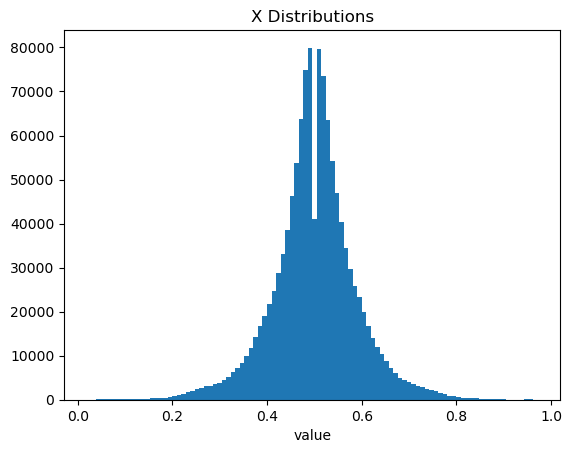

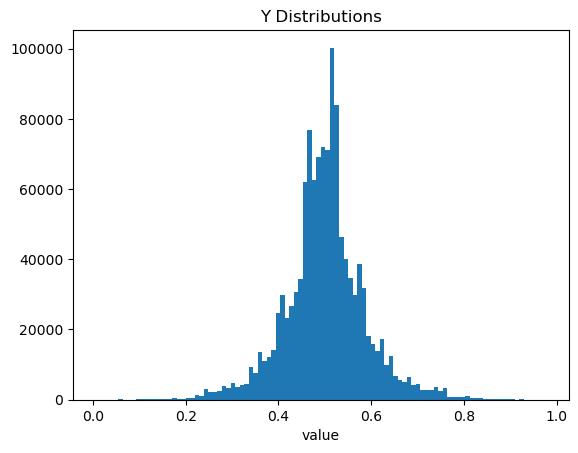

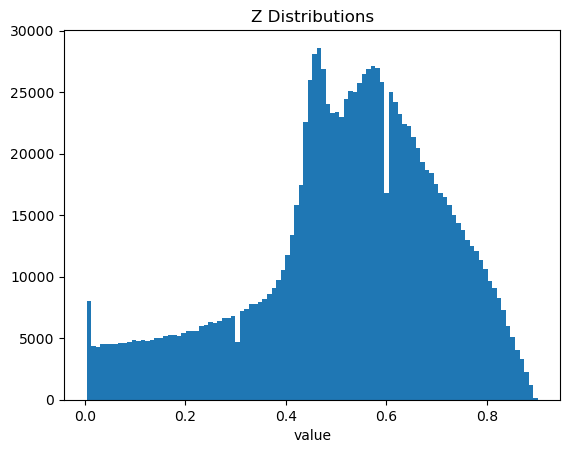

In [14]:
print(data[:,:,0].flatten())
plt.hist(data[:,:,0].flatten(), bins=100)
plt.xlabel('value')
plt.title('X Distributions')
plt.show()

plt.hist(data[:,:,1].flatten(), bins=100)
plt.xlabel('value')
plt.title('Y Distributions')
plt.show()

plt.hist(data[:,:,2].flatten(), bins=100)
plt.xlabel('value')
plt.title('Z Distributions')
plt.show()

### Assertion statements to check if coords are within unit cube

In [15]:
name = ISOTOPE + '_size' + str(sample_size) + '_sampled_normal'
data = np.load('voxel_data/' + name + '.npy')

assert np.amin(data[:,:,0]) > 0, 'There are x-values that are negative'
assert np.amin(data[:,:,1]) > 0, 'There are y-values that are negative'
assert np.amin(data[:,:,2]) > 0, 'There are z-values that are negative'
assert np.amax(data[:,:,0]) < 1, 'There are x-values that are greater than 1'
assert np.amax(data[:,:,1]) < 1, 'There are y-values that are greater than 1'
assert np.amax(data[:,:,2]) < 1, 'There are z-values that are greater than 1'

### Voxelizing and Labeling

In [16]:
name = ISOTOPE + '_size' + str(sample_size) + '_sampled_normal' # Using normalized data
data = np.load('voxel_data/' + name + '.npy')

K = 3 # Voxel resolution

new_data = np.zeros((len(data), sample_size, 6), float)

#Store voxel bounds in dict with keys being lists
#Structure: voxel[key] = [ [voxel_lower_bounds], [voxel_upper_bounds], voxel_id]
voxels = dict({})
i=0
for z in range(K):
    for y in range(K):
        for x in range(K):
            key = [x,y,z]
            value = []
            #Creating lower bound of voxel
            min_bounds = [-1,-1,-1]
            min_bounds[0] = (1/K)*x
            min_bounds[1] = (1/K)*y
            min_bounds[2] = (1/K)*z
            #Creating upper bound of voxel
            max_bounds = [-2,-2,-2]
            max_bounds[0] = (1/K) + (1/K)*x
            max_bounds[1] = (1/K) + (1/K)*y
            max_bounds[2] = (1/K) + (1/K)*z
            
            value.append(min_bounds)
            value.append(max_bounds)
            value.append(i)
            i += 1
            
            voxels[str(key)] = value
                  
#Identifying voxel id for each point and normalizing all points to be within [1/K,1/K,1/K]
# each instance will index according to the following 
# 0-x, 1-y, 2-z, 3-voxel id, 4-number of tracks, 5-event #
for i in tqdm.tqdm(range(len(data))):
    for j in range(sample_size):
        
        #Finding Current Point's Voxel Key
        voxel_key = [-1,-1,-1]
        x_val = data[i,j,0]
        if x_val < (1/K):
            voxel_key[0] = 0
        elif x_val > ((1/K)*2):
            voxel_key[0] = 2
        else:
            voxel_key[0] = 1

        y_val = data[i,j,1]
        if y_val < (1/K):
            voxel_key[1] = 0
        elif y_val > ((1/K)*2):
            voxel_key[1] = 2
        else:
            voxel_key[1] = 1

        z_val = data[i,j,2]
        if z_val < (1/K):
            voxel_key[2] = 0
        elif z_val > ((1/K)*2):
            voxel_key[2] = 2
        else:
            voxel_key[2] = 1
        
        #Getting related voxel info
        lower_bound = voxels[str(voxel_key)][0]
        upper_bound = voxels[str(voxel_key)][1]
        voxel_num = voxels[str(voxel_key)][2]

        #Normalizing coords
        new_x = x_val-lower_bound[0]
        new_y = y_val-lower_bound[1]
        new_z = z_val-lower_bound[2]
        
        #Saving new voxel coords and id
        new_data[i,j,0] = new_x
        new_data[i,j,1] = new_y
        new_data[i,j,2] = new_z
        data[i,j,3] = voxel_num
        new_data[i,j,3] = voxel_num
        data[i,j,4] = data[i,j,-1]
        new_data[i,j,4] = data[i,j,4]
        data[i,j,5] = str(i)
        new_data[i,j,5] = str(i)
        
# new_data[:,:,0] represents the x values, new_data[:,:,1] is y, and so on. So the cell prints the maxs and mins of x,y, and z values
print(np.amax(new_data[:,:,0]), np.amax(new_data[:,:,1]), np.amax(new_data[:,:,2]))
print(np.amin(new_data[:,:,0]), np.amin(new_data[:,:,1]), np.amin(new_data[:,:,2]))
  
#Converting all voxel keys from list to corresponding voxel id
i = 0
for z in range(K):
    for y in range(K):
        for x in range(K):
            key = [x,y,z]
            voxels[i] = voxels[str(key)]
            del voxels[str(key)]
            i += 1
            
new_array_name1 = ISOTOPE + '_size' + str(sample_size) + '_base_voxels.npy'
new_array_name2 = ISOTOPE + '_size' + str(sample_size) + '_voxelated.npy'

np.save('voxel_data/' + new_array_name1, new_data)
np.save('voxel_data/' + new_array_name2, data[:,:,:6]) # THIS is the file to use for incorporating unshuffled data in training set.

100%|██████████| 2426/2426 [00:06<00:00, 375.24it/s]


0.33158015830844056 0.33051446652879907 0.33283018867924524
0.0017531451056985725 0.002818866804534359 0.0012578616352201255


In [17]:
voxels_np = np.zeros((K**3,2,3))
for i in range(K**3):
    min_bounds = voxels[i][0]
    max_bounds = voxels[i][1]
    voxels_np[i,0] = min_bounds
    voxels_np[i,1] = max_bounds

# print(voxels)
# print(voxels_np)
np.save('voxel_data/voxel_bounds.npy', voxels_np)

In [18]:
name1 = ISOTOPE + '_size' + str(sample_size) + '_voxelated'
name2 = ISOTOPE + '_size' + str(sample_size) + '_base_voxels'
voxel_data = np.load('voxel_data/' + name1 + '.npy')
next_step_data = np.load('voxel_data/' + name2 + '.npy')

print(voxel_data.shape, next_step_data.shape)

assert voxel_data.shape == (count, sample_size, 6), 'Voxelated Shape is incorrect'
assert next_step_data.shape == (count, sample_size, 6), 'Base Voxels Shape is incorrect'

(2426, 512, 6) (2426, 512, 6)


### Shuffling and Randomly Augmenting Voxels

In [19]:
name = ISOTOPE + '_size' + str(sample_size) + '_base_voxels'
name_unshuffled = ISOTOPE + '_size' + str(sample_size) + '_voxelated'
data = np.load('voxel_data/' + name + '.npy')
data_unshuffled = np.load('voxel_data/' + name_unshuffled + '.npy')

new_data = np.zeros((len(data), sample_size, 6), float)
for i in tqdm.tqdm(range(len(data))):
    
    #Gets a list of where each voxel is going to be shuffled
    #Repeats until each voxel is assigned an id other than its own
    flag = True
    while flag:
        permutations = []
        ids = []
        overlap = False
        for j in range(K**3):
            ids.append(j)
        for j in range(K**3):
            val = random.choice(ids)
            permutations.append(val)
            ids.remove(val)
        for j,x in enumerate(permutations):
            if j == x:
                overlap = True
        if overlap == False:
            flag = False
            
    #Moves each point to its new voxel        
    for j in range(sample_size):
        augment = 0
        #Optional random augmentaion (slightly changing xyz) for better generalization
        # rand = random.randint(1, 100)
        # if rand < 17:
            #Maximum point can shift is 1/20 of a unit cube
            #augment = (random.random())/20
            #if (rand%2) == 0:
                #augment = augment*-1
                  
        old_id = data[i,j,3]
        num_tracks = data[i,j,4]
        event_num = data[i,j,5]
        
        new_id = permutations[int(old_id)]
        new_min_bounds = voxels[new_id][0]
        new_x = data[i,j,0] + new_min_bounds[0] + augment
        new_y = data[i,j,1] + new_min_bounds[1] + augment
        new_z = data[i,j,2] + new_min_bounds[2] + augment
        
        #Doesn't include augment if causes point to move out of unit cube
        if (new_x < 0) or (new_x > 1):
            new_x = data[i,j,0] + new_min_bounds[0]
        if (new_y < 0) or (new_y > 1):
            new_y = data[i,j,1] + new_min_bounds[1]
        if (new_z < 0) or (new_z > 1):
            new_z = data[i,j,2] + new_min_bounds[2]
            
        new_data[i,j,0] = new_x
        new_data[i,j,1] = new_y
        new_data[i,j,2] = new_z
        new_data[i,j,3] = old_id
        new_data[i,j,4] = num_tracks
        new_data[i,j,5] = event_num
        
final_data = np.concatenate((data_unshuffled[:1000],new_data),axis=0) 
# Use the above line to change the proportions of unshuffled and shuffled data in the training set

print(final_data.shape)
# to confirm concatenation occured correctly

shuffled_data = ISOTOPE + '_size' + str(sample_size) + '_shuffled_voxels_only' # Only shuffled
np.save('voxel_data/' + shuffled_data, new_data)

new_array_name = ISOTOPE + '_size' + str(sample_size) + '_shuffled_voxels' # Includes unshuffled
np.save('voxel_data/' + new_array_name, final_data)

100%|██████████| 2426/2426 [00:04<00:00, 568.66it/s]


(3426, 512, 6)


### Assertion statements to check if coords are still within unit cube

In [20]:
name = ISOTOPE + '_size' + str(sample_size) + '_shuffled_voxels'
data = np.load('voxel_data/' + name + '.npy')

assert np.amin(data[:,:,0]) > 0, 'There are x-values that are negative'
assert np.amin(data[:,:,1]) > 0, 'There are y-values that are negative'
assert np.amin(data[:,:,2]) > 0, 'There are z-values that are negative'
assert np.amax(data[:,:,0]) < 1, 'There are x-values that are greater than 1'
assert np.amax(data[:,:,1]) < 1, 'There are y-values that are greater than 1'
assert np.amax(data[:,:,2]) < 1, 'There are z-values that are greater than 1'

# Split Testing Set, Training Set, and Validation Set

## Split Training and Testing Sets

In [21]:
# performs a 20-test 20-val 60-train split on all 4-track events
# generates an array of numbers as long as the length of the data to randomize the events 

In [23]:
name = ISOTOPE + '_size' + str(sample_size)
all_events = np.load('voxel_data/' + name + '_shuffled_voxels.npy')
rand_shuffle = np.random.choice(len(all_events), len(all_events), replace = False)


# 20-20 marking for test and validation
test_split = int(len(all_events) * .2)
val_split = int(len(all_events) * .4)


test_data =  all_events[rand_shuffle[:test_split],:,:]    #only saving the indices and number of tracks of the test events
val_data = all_events[rand_shuffle[test_split:val_split],:,:]
train_data = all_events[rand_shuffle[val_split:],:,:]


print(test_data.shape, val_data.shape, train_data.shape)
np.save('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'test', test_data)
np.save('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'train', train_data)
np.save('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'val', val_data)

(685, 512, 6) (685, 512, 6) (2056, 512, 6)


# Making Test Sets

In [24]:
prev_data = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + '_sampled.npy')
tr = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'train.npy')
va = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'val.npy')
te = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'test.npy')

#works perfect if length of dataset is even, if odd, rounding may be off
#assert tr.shape == (np.ceil(len(prev_data) * .6) , sample_size, 4), 'Array has incorrect shape, check first for rounding error.'
#assert va.shape == (np.ceil(len(prev_data) * .2) , sample_size, 4), 'Array has incorrect shape, check first for rounding error.'
#assert te.shape == (np.ceil(len(prev_data) * .2) , sample_size, 4), 'Array has incorrect shape, check first for rounding error.'
print(len(prev_data))
print(tr.shape, va.shape, te.shape)
print(len(np.unique(tr[:,:,3])))

10000
(2056, 512, 6) (685, 512, 6) (685, 512, 6)
27


## Checking Test, Training, and Validation

In [25]:
check = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'train.npy')
check2 = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'val.npy')
check3 = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'test.npy')


print(check.shape)
print(check2.shape)
print(check3.shape)
print('')

print(check[1][0][:])
print('')

print(len(np.unique(check[:,:,3])))
print(len(np.unique(check2[:,:,3])))
print(len(np.unique(check3[:,:,3])))

(2056, 512, 6)
(685, 512, 6)
(685, 512, 6)

[8.52581342e-01 7.72146375e-01 5.98742138e-02 1.30000000e+01
 3.00000000e+00 1.20300000e+03]

27
26
27


# Checking data sets

In [26]:
#load in test, val, and train np arrays
test = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'test.npy')
train = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'train.npy')
val = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'val.npy')

In [27]:
#ASSERT
train = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'train.npy')
test = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'test.npy')
val = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'val.npy')

assert np.sum(np.isnan(train)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(test)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(val)) == 0, 'NaNs in dataset'
assert np.sum(np.isinf(train)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(test)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(val)) == 0, 'Infinities in dataset'

# Make Histogram

2


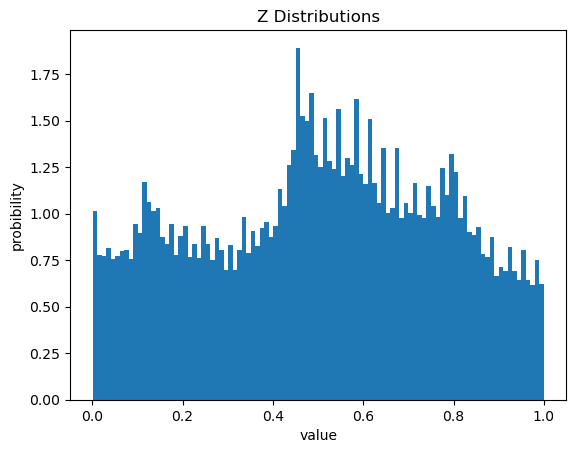

In [28]:
# Make histogram of values (either x,y,z,charge) from selected npy (train, val, test)
# Will need to change PLOT and DATA_SET_NAME to plot X-Y-Z-Q(charge) from training, val, or test
PLOT = 'Z'
DATA_SET_NAME = 'train'
index = PROJECTION.find(PLOT)
print(index)

if index != -1: #So that it is either X, Y or Z (0,1 or 2 indices)
    data = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + DATA_SET_NAME + '.npy')
    info = data[:,:,index].flatten()
    plt.hist(info, density=True, bins=100)
    plt.ylabel('probibility')
    plt.xlabel('value')
    plt.title(PLOT + ' Distributions')
    plt.show()
    # plt.savefig('data/'+ '.png', bbox_inches = 'tight') # uncomment to save
else:
    print('Value to plot is invalid, change PLOT')

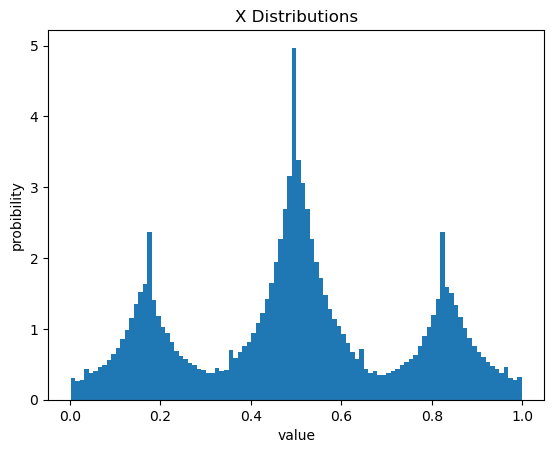

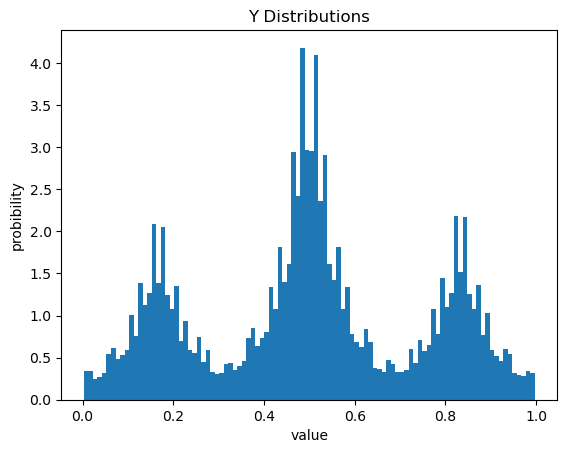

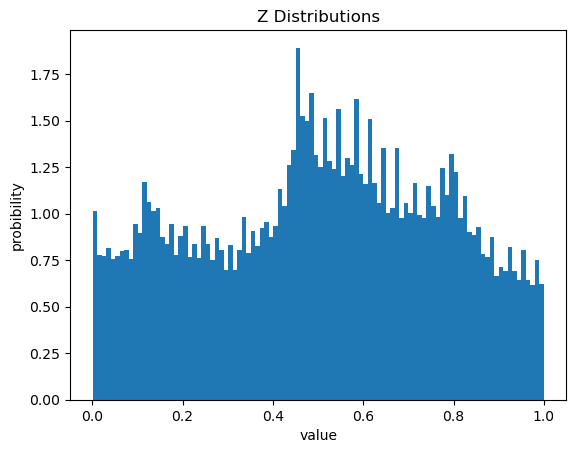

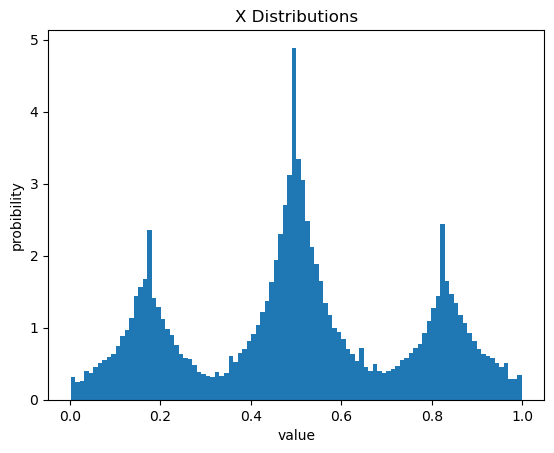

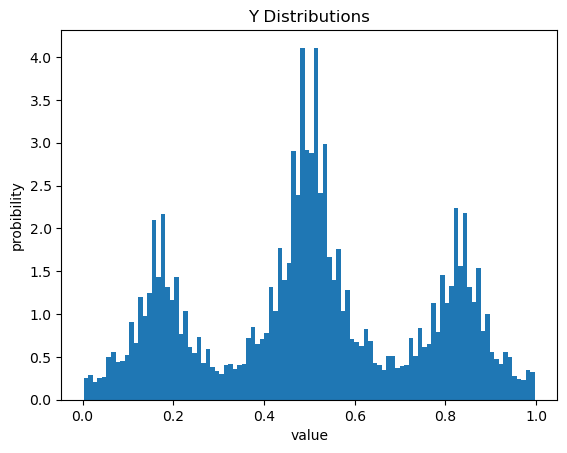

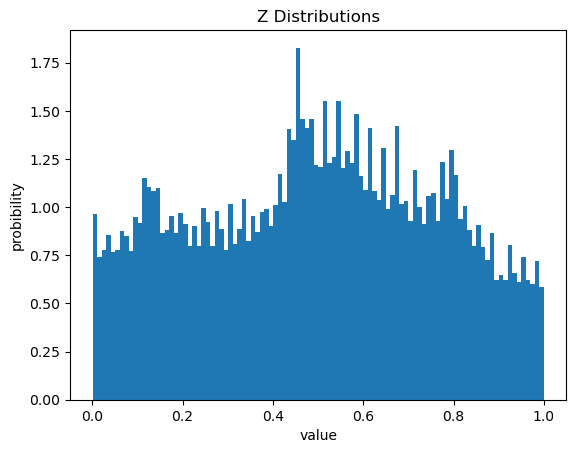

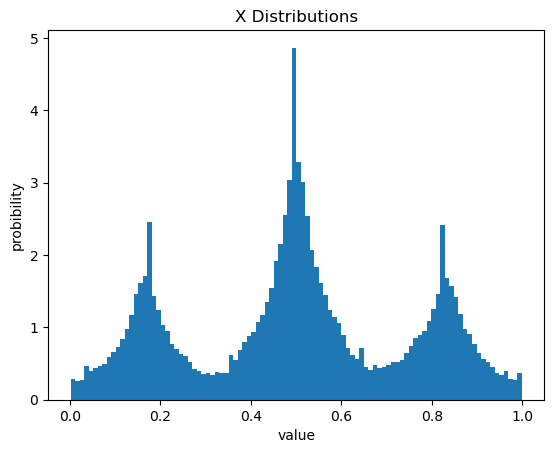

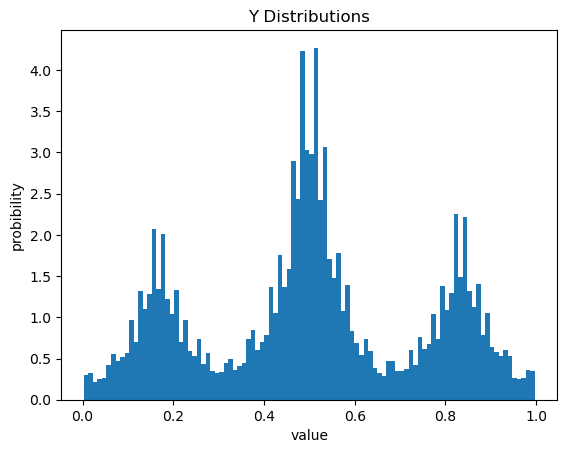

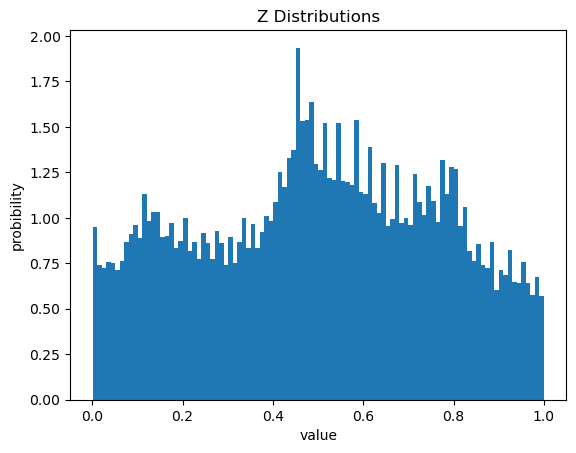

In [29]:
#plotting the x,y,and z distributions for training,validation, and test sets

CLASSIFICATION = 'BINARY'
class_type = CLASSIFICATION
PROJECTION = 'XYZ'
ISOTOPE = 'Mg22'
PLOT = ['X', 'Y','Z']
DATA_SET_NAME = ['train','val','test']
for i in DATA_SET_NAME:
    for j in PLOT:
        index = PROJECTION.find(j)
        if index != -1:
            data = np.load('voxel_data/' +ISOTOPE+ '_size'+ str(sample_size) +i+ '.npy')
            info = data[:,:,index].flatten()
            plt.hist(info, density=True, bins=100)
            plt.ylabel('probibility')
            plt.xlabel('value')
            plt.title(j + ' Distributions')
            plt.show()
            #plt.savefig('data/' +i+j+ '.png', bbox_inches = 'tight') 
        else:
            print('Value to plot is invalid, change PLOT')#

In [30]:
name = ISOTOPE + '_size' + str(sample_size) + '_voxelated'
data = np.load('voxel_data/' + name + '.npy')

for i in range(len(data)):
    for j in range(512):
        if data[i,j,4] == 5:
            print(data[i,j,5])
print(ISOTOPE)

516.0
1077.0
1173.0
1478.0
2026.0
Mg22


In [32]:
test = np.load('voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'test.npy')

event_nums = np.zeros((len(test),))
for i in range(len(test)):
    event_nums[i] = test[i,0,5]
    
